In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
start_date = '2010-01-01'
end_date = '2025-01-01'
stock_name = 'AAPL'

df = yf.download(stock_name, start=start_date, end=end_date)
df.reset_index(inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_1124\3372292005.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_name, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [4]:
df.columns = df.columns.droplevel(1)
df.columns
df

Price,Date,Close,High,Low,Open,Volume
0,2010-01-04,6.431896,6.446623,6.382908,6.414465,493729600
1,2010-01-05,6.443017,6.479382,6.409055,6.449629,601904800
2,2010-01-06,6.340533,6.468564,6.333921,6.443018,552160000
3,2010-01-07,6.328811,6.371488,6.282828,6.363974,477131200
4,2010-01-08,6.370886,6.371487,6.283128,6.320395,447610800
...,...,...,...,...,...,...
3769,2024-12-24,257.578674,257.588630,254.675658,254.875189,23234700
3770,2024-12-26,258.396667,259.474086,257.010028,257.568678,27237100
3771,2024-12-27,254.974930,258.077462,252.451019,257.209530,42355300
3772,2024-12-30,251.593094,252.889969,250.146586,251.623020,35557500


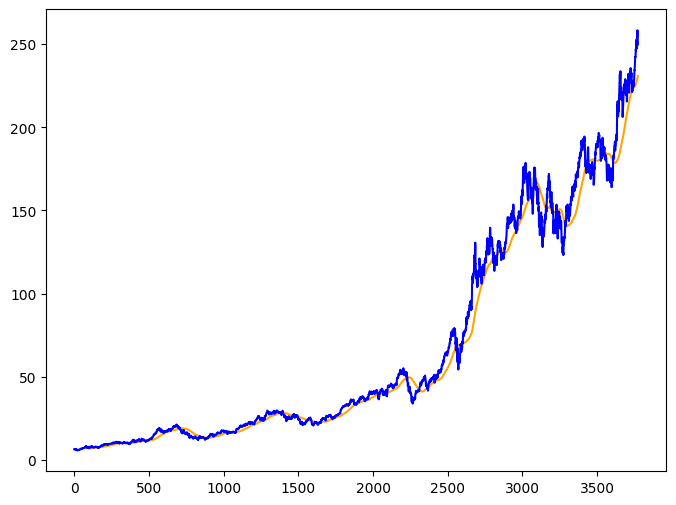

In [5]:
ma_100_days = df.Close.rolling(window=100).mean()
plt.figure(figsize=(8, 6))
plt.plot(ma_100_days, label='100-Day Moving Average', color='orange')
plt.plot(df.Close, label='Close Price', color='blue')
plt.show()

In [6]:
df.dropna(inplace=True)

In [7]:
df_train = pd.DataFrame(df.Close[0:int(len(df)*0.8)])
df_test = pd.DataFrame(df.Close[int(len(df)*0.8):])

In [8]:
df_train.shape[0]

3019

In [9]:
df_test.shape[0]

755

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_train_scale = scaler.fit_transform(df_train)
data_train_scale


array([[0.00385452],
       [0.00391947],
       [0.00332093],
       ...,
       [1.        ],
       [0.99403826],
       [0.99455424]])

In [11]:
x = []
y = []
for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i, 0])
    y.append(data_train_scale[i, 0])

In [12]:
x,y = np.array(x), np.array(y)

In [13]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True, input_shape = (x.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu',return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))


c:\Users\dell\Desktop\Neural-Network\Finance\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [15]:
model.fit(x, y, epochs=50, batch_size=32,verbose = 1)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 481ms/step - loss: 0.0351
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 547ms/step - loss: 0.0039
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 559ms/step - loss: 0.0042
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 523ms/step - loss: 0.0031
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 484ms/step - loss: 0.0026
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 499ms/step - loss: 0.0021
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 324ms/step - loss: 0.0025
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 330ms/step - loss: 0.0022
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 342ms/step - loss: 0.0017
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 336ms/step - loss: 0.0020
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 361ms/step - loss: 0.0018
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 346ms/step - loss: 0.0019
Epoch 13/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 345ms/step - loss: 0.0017
Epoch 14/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - loss: 0.0018
Epoch 15/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [17]:
pas_100_days = df_train.tail(100)
pas_100_days

,Close
2919,143.180618
2920,142.700394
2921,142.955215
2922,145.924896
2923,146.130707
...,...
3014,172.393372
3015,173.021561
3016,176.996719
3017,175.975922


In [24]:
data_test = pd.concat((pas_100_days, df_test), ignore_index=True)
data_test_scale = scaler.fit_transform(data_test)

In [36]:
x = []
y = []
for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i, 0])
    y.append(data_test_scale[i, 0])
x,y = np.array(x), np.array(y)

In [44]:
y_pred = model.predict(x)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step


In [38]:
invscal = 1/scaler.scale_

In [47]:
y_pred = y_pred * invscal
y = y * invscal

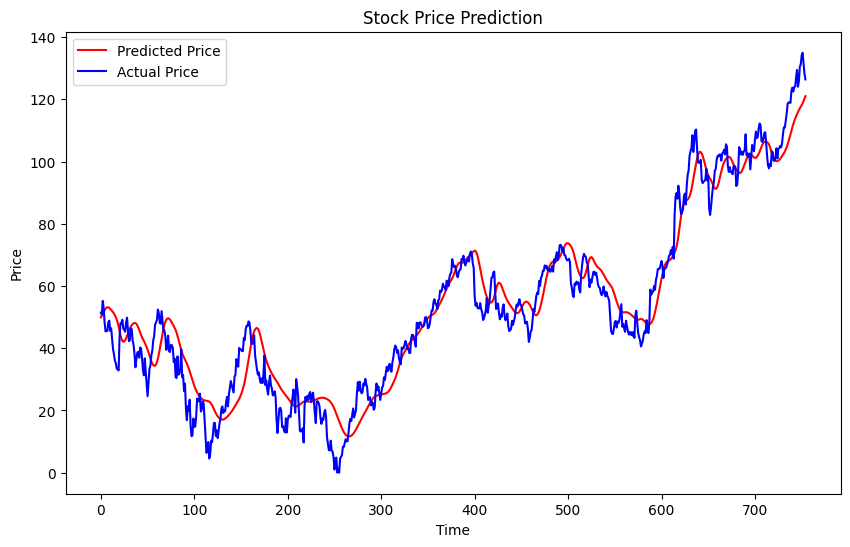

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(y_pred,'r',label='Predicted Price')
plt.plot(y,'b',label='Actual Price')
plt.xlabel('Time')
plt.ylabel('Price') 
plt.title('Stock Price Prediction')
plt.legend()
plt.show()

In [ ]:
#model.save('stock_price_prediction_model.keras')